In [2]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 15.6 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, ttest_ind
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

OUTPUT_DIR = Path("protein_level_differentials")
OUTPUT_DIR.mkdir(exist_ok=True)

RAW_VARIANTS_FILE = Path("variants_tmt.tsv")
FILTERED_WITH_LABELS_FILE = Path("variants_filtered_with_labels.tsv")
FILTERED_FEATURES_FILE = Path("variants_filtered.tsv")
FILTERED_LABELS_FILE = Path("variants_filtered_labels.tsv")

PEPTIDE_DIFF_FILE = Path("peptide_differentials/peptide_differentials_selected_rank_1_2_6_feature_stats.tsv")
TOP_FEATURES_FILE = Path("peptide_differentials/top_model_features.tsv")

PROTEIN_ID_TOP3_FILE = Path("protein_identification_outputs_top3/top3_peptide_protein_identification_table.tsv")

SEVERE_LABEL = "Severe-COVID-19"
NONSEVERE_LABEL = "Non-severe-COVID-19"

ALPHA = 0.05
MIN_VALID_PER_GROUP = 3
MISSINGNESS_WARN_THRESHOLD = 50.0

In [4]:
def load_patient_matrix():
    if FILTERED_WITH_LABELS_FILE.exists():
        df = pd.read_csv(FILTERED_WITH_LABELS_FILE, sep="\t", index_col=0)
        if "Condition" not in df.columns:
            raise ValueError("variants_filtered_with_labels.tsv exists but has no Condition column.")
        condition = df["Condition"].copy()
        X = df.drop(columns=["Condition"])
        return X, condition

    df = pd.read_csv(FILTERED_FEATURES_FILE, sep="\t", index_col=0)

    if "Condition" in df.columns:
        condition = df["Condition"].copy()
        X = df.drop(columns=["Condition"])
        return X, condition

    if not FILTERED_LABELS_FILE.exists():
        raise FileNotFoundError(
            "Could not find labels. Expected either a Condition column in variants_filtered.tsv "
            "or a separate variants_filtered_labels.tsv file."
        )

    labels = pd.read_csv(FILTERED_LABELS_FILE, sep="\t", index_col=0)
    condition = labels["Condition"].copy()
    X = df.copy()

    return X, condition


X, condition = load_patient_matrix()

keep = condition.isin([SEVERE_LABEL, NONSEVERE_LABEL])
X = X.loc[keep].copy()
condition = condition.loc[keep].copy()

print("Patient-feature matrix:", X.shape)
print(condition.value_counts())

Patient-feature matrix: (43, 101461)
Condition
Non-severe-COVID-19    25
Severe-COVID-19        18
Name: count, dtype: int64


In [5]:
raw = pd.read_csv(RAW_VARIANTS_FILE, sep="\t", low_memory=False)

print("Raw variants_tmt shape:", raw.shape)
print("First 30 columns:")
print(raw.columns[:30].tolist())


def find_column(df, candidates, required=True):
    lower_to_original = {c.lower(): c for c in df.columns}

    for candidate in candidates:
        if candidate.lower() in lower_to_original:
            return lower_to_original[candidate.lower()]

    for col in df.columns:
        col_lower = col.lower()
        for candidate in candidates:
            if candidate.lower() in col_lower:
                return col

    if required:
        raise ValueError(f"Could not find any of these columns: {candidates}")

    return None


PEPTIDE_COL = find_column(raw, ["Peptide", "peptide", "variant", "PeptideVariant"])
PROTEIN_COL = find_column(
    raw,
    [
        "Protein",
        "Proteins",
        "protein",
        "proteins",
        "Protein Accession",
        "ProteinAccessions",
        "protein_accession",
        "accession",
    ],
    required=False,
)

if PROTEIN_COL is None:
    print("Could not automatically identify protein column.")
    print("Columns containing 'protein':")
    print([c for c in raw.columns if "protein" in c.lower()])
    raise ValueError("Set PROTEIN_COL manually after inspecting the printed columns.")

print("Peptide column:", PEPTIDE_COL)
print("Protein column:", PROTEIN_COL)

Raw variants_tmt shape: (101461, 268)
First 30 columns:
['rowid', 'ccms_row_id', 'Algorithm', 'Filename', 'Cluster_index', 'Peptide', 'Unmodified_sequence', 'Charge', '_dyn_#Intensity_for_cluster', '_dyn_#Intensity_for_unmodified_sequence', 'Num_G1_spectra_for_unmodified_sequence', 'Num_G2_spectra_for_unmodified_sequence', 'Num_G3_spectra_for_unmodified_sequence', 'Num_G4_spectra_for_unmodified_sequence', 'Num_G5_spectra_for_unmodified_sequence', 'Num_G6_spectra_for_unmodified_sequence', '_dyn_#Empty.Empty.Empty..Empty.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC1.Healthy..HC1.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC10.Healthy..HC10.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC12.Healthy..HC12.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC13.Healthy..HC13.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC17.Healthy..HC17.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC19.Healthy..HC19.1_intensity_for_unmodified_sequence', '_dyn_#

In [7]:
def split_proteins(value):
    if pd.isna(value):
        return []

    text = str(value).strip()
    if text == "":
        return []

    # Split on common separators
    parts = re.split(r"[;,]\s*|\s+", text)
    parts = [p.strip() for p in parts if p.strip()]

    # Keep full UniProt-style accessions when present
    proteins = []
    for p in parts:
        p = p.strip()
        if p and p not in proteins:
            proteins.append(p)

    return proteins


def protein_short_name(protein):
    """
    sp|P02787|TRFE_HUMAN -> TRFE_HUMAN
    P02787 -> P02787
    """
    if not isinstance(protein, str):
        return protein

    if "|" in protein:
        fields = protein.split("|")
        if len(fields) >= 3:
            return fields[2]

    return protein


annotation = raw[[PEPTIDE_COL, PROTEIN_COL]].copy()
annotation = annotation.rename(columns={PEPTIDE_COL: "Peptide", PROTEIN_COL: "ProteinRaw"})
annotation["ProteinList"] = annotation["ProteinRaw"].apply(split_proteins)
annotation["n_mapped_proteins"] = annotation["ProteinList"].apply(len)
annotation["is_unique_mapping"] = annotation["n_mapped_proteins"].eq(1)

annotation.head()

,Peptide,ProteinRaw,ProteinList,n_mapped_proteins,is_unique_mapping
0,"K.[304.207]GARLIPEMDQIFTEVEMTTLE(K,304.207).V",sp|Q9Y4L1|HYOU1_HUMAN; tr|A0A087X054|A0A087X05...,"[sp|Q9Y4L1|HYOU1_HUMAN, tr|A0A087X054|A0A087X0...",3,False
1,"I.[304.207]FTEVEMTTLE(K,304.207).V",sp|Q9Y4L1|HYOU1_HUMAN; tr|A0A087X054|A0A087X05...,"[sp|Q9Y4L1|HYOU1_HUMAN, tr|A0A087X054|A0A087X0...",3,False
2,K.[304.207]LYQPEYQEVSTEEQR.E,sp|Q9Y4L1|HYOU1_HUMAN; tr|A0A087X054|A0A087X05...,"[sp|Q9Y4L1|HYOU1_HUMAN, tr|A0A087X054|A0A087X0...",3,False
3,"K.[304.207]AANSLEAFIFETQD(K,304.207).L",sp|Q9Y4L1|HYOU1_HUMAN; tr|A0A087X054|A0A087X05...,"[sp|Q9Y4L1|HYOU1_HUMAN, tr|A0A087X054|A0A087X0...",3,False
4,"R.[304.207]YSHDF(N,-56.985)FH.I",sp|Q9Y4L1-2|HYOU1_HUMAN; sp|Q9Y4L1|HYOU1_HUMAN...,"[sp|Q9Y4L1-2|HYOU1_HUMAN, sp|Q9Y4L1|HYOU1_HUMA...",7,False


In [8]:
selected_peptides = pd.read_csv(PEPTIDE_DIFF_FILE, sep="\t")

print(selected_peptides.shape)
display(selected_peptides)

target_peptides = selected_peptides["Peptide"].tolist()
target_peptides

(3, 18)


,model_rank,Peptide,coefficient,model_direction,n_severe,n_nonsevere,missing_pct_severe,missing_pct_nonsevere,missingness_flag,median_severe,median_nonsevere,log2FC_median_severe_vs_nonsevere,mannwhitney_pvalue,mannwhitney_fdr,welch_t_pvalue,welch_t_fdr,da_direction,significance_flag
0,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",-0.291871,Higher in non-severe by model,12,15,33.333333,40.0,moderate missingness,0.535599,1.290021,-0.576559,0.000696,1.000000,0.000435,0.999969,Higher median intensity in non-severe,raw p < 0.05 only
1,2,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",-0.240642,Higher in non-severe by model,18,25,0.000000,0.0,low missingness,0.712057,1.767070,-0.692628,0.000042,0.832764,0.000011,0.713465,Higher median intensity in non-severe,raw p < 0.05 only
2,6,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",0.040224,Higher in severe by model,18,25,0.000000,0.0,low missingness,0.821407,0.168800,0.640026,0.001107,1.000000,0.003137,0.999969,Higher median intensity in severe,raw p < 0.05 only


['S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K',
 'R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57.021)(K,304.207)PV(K,304.207).W',
 'R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C,57.021)EE(K,304.207).S']

In [9]:
target_mapping_rows = []

for _, row in selected_peptides.iterrows():
    peptide = row["Peptide"]
    model_rank = row.get("model_rank", np.nan)
    peptide_direction = row.get("da_direction", row.get("model_direction", ""))

    matches = annotation[annotation["Peptide"] == peptide]

    if matches.empty:
        target_mapping_rows.append({
            "model_rank": model_rank,
            "target_peptide": peptide,
            "target_peptide_direction": peptide_direction,
            "protein": np.nan,
            "protein_short": np.nan,
            "target_peptide_n_mapped_proteins": 0,
            "target_peptide_unique_mapping": False,
        })
        continue

    proteins = []
    for protein_list in matches["ProteinList"]:
        proteins.extend(protein_list)

    proteins = sorted(set(proteins))

    for protein in proteins:
        target_mapping_rows.append({
            "model_rank": model_rank,
            "target_peptide": peptide,
            "target_peptide_direction": peptide_direction,
            "protein": protein,
            "protein_short": protein_short_name(protein),
            "target_peptide_n_mapped_proteins": len(proteins),
            "target_peptide_unique_mapping": len(proteins) == 1,
        })

target_mapping = pd.DataFrame(target_mapping_rows)

target_mapping.to_csv(
    OUTPUT_DIR / "target_peptide_to_protein_mapping.tsv",
    sep="\t",
    index=False,
)

display(target_mapping)

,model_rank,target_peptide,target_peptide_direction,protein,protein_short,target_peptide_n_mapped_proteins,target_peptide_unique_mapping
0,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",Higher median intensity in non-severe,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,5,False
1,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",Higher median intensity in non-severe,sp|P01877|IGHA2_HUMAN,IGHA2_HUMAN,5,False
2,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",Higher median intensity in non-severe,tr|A0A0G2JMB2|A0A0G2JMB2_HUMAN,A0A0G2JMB2_HUMAN,5,False
3,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",Higher median intensity in non-severe,tr|A0A286YEY1|A0A286YEY1_HUMAN,A0A286YEY1_HUMAN,5,False
4,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",Higher median intensity in non-severe,tr|A0A286YEY5|A0A286YEY5_HUMAN,A0A286YEY5_HUMAN,5,False
5,2,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",Higher median intensity in non-severe,sp|P02787|TRFE_HUMAN,TRFE_HUMAN,1,True
6,6,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",Higher median intensity in severe,sp|P08603-2|CFAH_HUMAN,CFAH_HUMAN,4,False
7,6,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",Higher median intensity in severe,sp|P08603|CFAH_HUMAN,CFAH_HUMAN,4,False
8,6,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",Higher median intensity in severe,tr|A0A0D9SG88|A0A0D9SG88_HUMAN,A0A0D9SG88_HUMAN,4,False
9,6,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",Higher median intensity in severe,tr|Q5TFM2|Q5TFM2_HUMAN,Q5TFM2_HUMAN,4,False


In [10]:
candidate_proteins = sorted(target_mapping["protein"].dropna().unique())

protein_peptide_rows = []

for protein in candidate_proteins:
    for _, ann_row in annotation.iterrows():
        peptide = ann_row["Peptide"]
        proteins = ann_row["ProteinList"]
        n_proteins = ann_row["n_mapped_proteins"]

        if protein in proteins:
            protein_peptide_rows.append({
                "protein": protein,
                "protein_short": protein_short_name(protein),
                "peptide": peptide,
                "n_mapped_proteins": n_proteins,
                "is_unique_mapping": n_proteins == 1,
                "is_target_model_peptide": peptide in target_peptides,
            })

protein_peptides = pd.DataFrame(protein_peptide_rows).drop_duplicates()

protein_peptides.to_csv(
    OUTPUT_DIR / "candidate_protein_all_mapped_peptides.tsv",
    sep="\t",
    index=False,
)

print("Candidate proteins:", len(candidate_proteins))
print("Protein-peptide rows:", protein_peptides.shape)
display(protein_peptides.head())

Candidate proteins: 10
Protein-peptide rows: (12123, 6)


,protein,protein_short,peptide,n_mapped_proteins,is_unique_mapping,is_target_model_peptide
0,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"V.[304.207]MAEVDGT(C,57.021)Y.-",2,False,False
1,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVV(M,16.005)AE...",2,False,False
2,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVV(M,15.015)AE...",2,False,False
3,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVVMAEVDGT(C,57...",2,False,False
4,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVV(M,16.003)AE...",2,False,False


In [14]:
def safe_log2fc(median_severe, median_nonsevere, pseudocount=1e-9):
    return np.log2((median_severe + pseudocount) / (median_nonsevere + pseudocount))


def compute_peptide_da(peptide):
    if peptide not in X.columns:
        return None

    values = X[peptide]

    severe_vals = values[condition == SEVERE_LABEL].dropna()
    nonsevere_vals = values[condition == NONSEVERE_LABEL].dropna()

    n_severe = len(severe_vals)
    n_nonsevere = len(nonsevere_vals)

    total_severe = int((condition == SEVERE_LABEL).sum())
    total_nonsevere = int((condition == NONSEVERE_LABEL).sum())

    missing_pct_severe = 100.0 * (1 - n_severe / total_severe)
    missing_pct_nonsevere = 100.0 * (1 - n_nonsevere / total_nonsevere)
    max_missing_pct = max(missing_pct_severe, missing_pct_nonsevere)

    median_severe = severe_vals.median() if n_severe > 0 else np.nan
    median_nonsevere = nonsevere_vals.median() if n_nonsevere > 0 else np.nan

    log2fc = safe_log2fc(median_severe, median_nonsevere)

    if n_severe >= MIN_VALID_PER_GROUP and n_nonsevere >= MIN_VALID_PER_GROUP:
        try:
            _, mw_p = mannwhitneyu(severe_vals, nonsevere_vals, alternative="two-sided")
        except Exception:
            mw_p = np.nan

        try:
            _, t_p = ttest_ind(severe_vals, nonsevere_vals, equal_var=False, nan_policy="omit")
        except Exception:
            t_p = np.nan
    else:
        mw_p = np.nan
        t_p = np.nan

    if pd.isna(log2fc):
        direction = "not_testable"
    elif log2fc > 0:
        direction = "Severe ↑"
    elif log2fc < 0:
        direction = "Non-severe ↑"
    else:
        direction = "no_change"

    return {
        "n_severe": n_severe,
        "n_nonsevere": n_nonsevere,
        "missing_pct_severe": missing_pct_severe,
        "missing_pct_nonsevere": missing_pct_nonsevere,
        "max_missing_pct": max_missing_pct,
        "median_severe": median_severe,
        "median_nonsevere": median_nonsevere,
        "log2FC_severe_vs_nonsevere": log2fc,
        "mannwhitney_pvalue": mw_p,
        "welch_t_pvalue": t_p,
        "direction": direction,
    }


da_rows = []

for _, row in protein_peptides.iterrows():
    peptide = row["peptide"]
    stats = compute_peptide_da(peptide)

    if stats is None:
        continue

    da_rows.append({
        **row.to_dict(),
        **stats,
    })

protein_peptide_da = pd.DataFrame(da_rows)

# FDR correction across all tested protein-mapped peptides
valid_mw = protein_peptide_da["mannwhitney_pvalue"].notna()

protein_peptide_da["mannwhitney_fdr"] = np.nan

if valid_mw.sum() > 0:
    protein_peptide_da.loc[valid_mw, "mannwhitney_fdr"] = multipletests(
        protein_peptide_da.loc[valid_mw, "mannwhitney_pvalue"],
        method="fdr_bh"
    )[1]

protein_peptide_da["raw_significant"] = protein_peptide_da["mannwhitney_pvalue"] < ALPHA
protein_peptide_da["fdr_significant"] = protein_peptide_da["mannwhitney_fdr"] < ALPHA
protein_peptide_da["low_missingness"] = protein_peptide_da["max_missing_pct"] <= MISSINGNESS_WARN_THRESHOLD

protein_peptide_da["usable_for_majority_rule"] = (
    protein_peptide_da["is_unique_mapping"]
    & protein_peptide_da["low_missingness"]
    & protein_peptide_da["mannwhitney_pvalue"].notna()
)

protein_peptide_da.to_csv(
    OUTPUT_DIR / "protein_level_all_unique_peptides.tsv",
    sep="\t",
    index=False,
)

print(protein_peptide_da.shape)
display(protein_peptide_da.head())

(12123, 22)


,protein,protein_short,peptide,n_mapped_proteins,is_unique_mapping,is_target_model_peptide,n_severe,n_nonsevere,missing_pct_severe,missing_pct_nonsevere,...,median_nonsevere,log2FC_severe_vs_nonsevere,mannwhitney_pvalue,welch_t_pvalue,direction,mannwhitney_fdr,raw_significant,fdr_significant,low_missingness,usable_for_majority_rule
0,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"V.[304.207]MAEVDGT(C,57.021)Y.-",2,False,False,3,3,83.333333,88.0,...,0.713162,0.055552,0.700000,0.890041,Severe ↑,1.0,False,False,False,False
1,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVV(M,16.005)AE...",2,False,False,16,22,11.111111,12.0,...,0.201311,0.597808,0.351690,0.488202,Severe ↑,1.0,False,False,True,False
2,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVV(M,15.015)AE...",2,False,False,9,13,50.000000,48.0,...,0.436537,-0.352680,0.738462,0.534599,Non-severe ↑,1.0,False,False,True,False
3,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVVMAEVDGT(C,57...",2,False,False,18,25,0.000000,0.0,...,0.213591,-0.113830,0.721118,0.623975,Non-severe ↑,1.0,False,False,True,False
4,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVV(M,16.003)AE...",2,False,False,16,22,11.111111,12.0,...,0.434492,-0.007738,0.778808,0.593003,Non-severe ↑,1.0,False,False,True,False


In [16]:
print("annotation columns:", annotation.columns.tolist())
print("target_mapping shape:", target_mapping.shape)
print("target_mapping columns:", target_mapping.columns.tolist())
display(target_mapping.head())

print("candidate_proteins:", candidate_proteins[:10])
print("number of candidate proteins:", len(candidate_proteins))

print("protein_peptides shape:", protein_peptides.shape)
print("protein_peptides columns:", protein_peptides.columns.tolist())
display(protein_peptides.head())

print("protein_peptide_da shape:", protein_peptide_da.shape)
print("protein_peptide_da columns:", protein_peptide_da.columns.tolist())
display(protein_peptide_da.head())

annotation columns: ['Peptide', 'ProteinRaw', 'ProteinList', 'n_mapped_proteins', 'is_unique_mapping']
target_mapping shape: (10, 7)
target_mapping columns: ['model_rank', 'target_peptide', 'target_peptide_direction', 'protein', 'protein_short', 'target_peptide_n_mapped_proteins', 'target_peptide_unique_mapping']


,model_rank,target_peptide,target_peptide_direction,protein,protein_short,target_peptide_n_mapped_proteins,target_peptide_unique_mapping
0,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",Higher median intensity in non-severe,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,5,False
1,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",Higher median intensity in non-severe,sp|P01877|IGHA2_HUMAN,IGHA2_HUMAN,5,False
2,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",Higher median intensity in non-severe,tr|A0A0G2JMB2|A0A0G2JMB2_HUMAN,A0A0G2JMB2_HUMAN,5,False
3,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",Higher median intensity in non-severe,tr|A0A286YEY1|A0A286YEY1_HUMAN,A0A286YEY1_HUMAN,5,False
4,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",Higher median intensity in non-severe,tr|A0A286YEY5|A0A286YEY5_HUMAN,A0A286YEY5_HUMAN,5,False


candidate_proteins: ['sp|P01876|IGHA1_HUMAN', 'sp|P01877|IGHA2_HUMAN', 'sp|P02787|TRFE_HUMAN', 'sp|P08603-2|CFAH_HUMAN', 'sp|P08603|CFAH_HUMAN', 'tr|A0A0D9SG88|A0A0D9SG88_HUMAN', 'tr|A0A0G2JMB2|A0A0G2JMB2_HUMAN', 'tr|A0A286YEY1|A0A286YEY1_HUMAN', 'tr|A0A286YEY5|A0A286YEY5_HUMAN', 'tr|Q5TFM2|Q5TFM2_HUMAN']
number of candidate proteins: 10
protein_peptides shape: (12123, 6)
protein_peptides columns: ['protein', 'protein_short', 'peptide', 'n_mapped_proteins', 'is_unique_mapping', 'is_target_model_peptide']


,protein,protein_short,peptide,n_mapped_proteins,is_unique_mapping,is_target_model_peptide
0,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"V.[304.207]MAEVDGT(C,57.021)Y.-",2,False,False
1,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVV(M,16.005)AE...",2,False,False
2,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVV(M,15.015)AE...",2,False,False
3,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVVMAEVDGT(C,57...",2,False,False
4,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVV(M,16.003)AE...",2,False,False


protein_peptide_da shape: (12123, 22)
protein_peptide_da columns: ['protein', 'protein_short', 'peptide', 'n_mapped_proteins', 'is_unique_mapping', 'is_target_model_peptide', 'n_severe', 'n_nonsevere', 'missing_pct_severe', 'missing_pct_nonsevere', 'max_missing_pct', 'median_severe', 'median_nonsevere', 'log2FC_severe_vs_nonsevere', 'mannwhitney_pvalue', 'welch_t_pvalue', 'direction', 'mannwhitney_fdr', 'raw_significant', 'fdr_significant', 'low_missingness', 'usable_for_majority_rule']


,protein,protein_short,peptide,n_mapped_proteins,is_unique_mapping,is_target_model_peptide,n_severe,n_nonsevere,missing_pct_severe,missing_pct_nonsevere,...,median_nonsevere,log2FC_severe_vs_nonsevere,mannwhitney_pvalue,welch_t_pvalue,direction,mannwhitney_fdr,raw_significant,fdr_significant,low_missingness,usable_for_majority_rule
0,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"V.[304.207]MAEVDGT(C,57.021)Y.-",2,False,False,3,3,83.333333,88.0,...,0.713162,0.055552,0.700000,0.890041,Severe ↑,1.0,False,False,False,False
1,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVV(M,16.005)AE...",2,False,False,16,22,11.111111,12.0,...,0.201311,0.597808,0.351690,0.488202,Severe ↑,1.0,False,False,True,False
2,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVV(M,15.015)AE...",2,False,False,9,13,50.000000,48.0,...,0.436537,-0.352680,0.738462,0.534599,Non-severe ↑,1.0,False,False,True,False
3,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVVMAEVDGT(C,57...",2,False,False,18,25,0.000000,0.0,...,0.213591,-0.113830,0.721118,0.623975,Non-severe ↑,1.0,False,False,True,False
4,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"R.[304.207]LAG(K,304.207)PTHVNVSVV(M,16.003)AE...",2,False,False,16,22,11.111111,12.0,...,0.434492,-0.007738,0.778808,0.593003,Non-severe ↑,1.0,False,False,True,False


In [ ]:
protein_peptide_da.groupby("protein", as_index=False).majority_rule_call()

In [21]:
def majority_rule_call(group):
    protein = group.name
    protein_short = group["protein_short"].iloc[0]

    unique = group[group["usable_for_majority_rule"]].copy()
    unique_sig = unique[unique["raw_significant"]].copy()

    n_total_mapped = group["peptide"].nunique()
    n_unique_testable = unique["peptide"].nunique()
    n_unique_sig = unique_sig["peptide"].nunique()

    severe_sig = unique_sig[unique_sig["direction"] == "Severe ↑"]
    nonsevere_sig = unique_sig[unique_sig["direction"] == "Non-severe ↑"]

    n_severe_sig = severe_sig["peptide"].nunique()
    n_nonsevere_sig = nonsevere_sig["peptide"].nunique()

    if n_unique_testable == 0:
        majority_direction = "insufficient_unique_testable_peptides"
        majority_fraction = np.nan
        effect_level = "inconclusive"
    else:
        severe_fraction = n_severe_sig / n_unique_testable
        nonsevere_fraction = n_nonsevere_sig / n_unique_testable

        if severe_fraction > 0.5:
            majority_direction = "Severe ↑"
            majority_fraction = severe_fraction
            effect_level = "protein-level effect"
        elif nonsevere_fraction > 0.5:
            majority_direction = "Non-severe ↑"
            majority_fraction = nonsevere_fraction
            effect_level = "protein-level effect"
        elif n_unique_sig > 0:
            majority_direction = "mixed_or_minority_signal"
            majority_fraction = max(severe_fraction, nonsevere_fraction)
            effect_level = "peptide-level effect"
        else:
            majority_direction = "no_consistent_differential_abundance"
            majority_fraction = 0.0
            effect_level = "no protein-level evidence"

    target_rows = group[group["is_target_model_peptide"]]
    target_peptides_for_protein = "; ".join(sorted(target_rows["peptide"].unique()))
    target_unique_mapping = bool(target_rows["is_unique_mapping"].all()) if len(target_rows) else False

    if len(target_rows) > 0 and not target_unique_mapping:
        mapping_caution = "target peptide maps to multiple proteins; protein-level assignment is ambiguous"
    elif len(target_rows) > 0 and target_unique_mapping:
        mapping_caution = "target peptide maps uniquely to this protein"
    else:
        mapping_caution = "protein connected indirectly; no target peptide row found"

    return pd.Series({
        "protein": protein,
        "protein_short": protein_short,
        "target_model_peptides": target_peptides_for_protein,
        "target_peptide_unique_mapping": target_unique_mapping,
        "n_total_mapped_peptides": n_total_mapped,
        "n_unique_testable_peptides": n_unique_testable,
        "n_unique_significant_peptides_raw_p": n_unique_sig,
        "n_unique_significant_severe_up": n_severe_sig,
        "n_unique_significant_nonsevere_up": n_nonsevere_sig,
        "majority_direction": majority_direction,
        "majority_fraction": majority_fraction,
        "effect_level_call": effect_level,
        "mapping_caution": mapping_caution,
    })


protein_majority_summary = (
    protein_peptide_da
    .groupby("protein", as_index=False)
    .apply(majority_rule_call)
    .reset_index(drop=True)
)

protein_majority_summary.to_csv(
    OUTPUT_DIR / "protein_level_majority_rule_summary.tsv",
    sep="\t",
    index=False,
)

display(protein_majority_summary)

,protein,protein_short,target_model_peptides,target_peptide_unique_mapping,n_total_mapped_peptides,n_unique_testable_peptides,n_unique_significant_peptides_raw_p,n_unique_significant_severe_up,n_unique_significant_nonsevere_up,majority_direction,majority_fraction,effect_level_call,mapping_caution
0,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",False,1463,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...
1,sp|P01877|IGHA2_HUMAN,IGHA2_HUMAN,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",False,654,1,0,0,0,no_consistent_differential_abundance,0.000000,no protein-level evidence,target peptide maps to multiple proteins; prot...
2,sp|P02787|TRFE_HUMAN,TRFE_HUMAN,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",True,4288,878,11,2,9,mixed_or_minority_signal,0.010251,peptide-level effect,target peptide maps uniquely to this protein
3,sp|P08603-2|CFAH_HUMAN,CFAH_HUMAN,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",False,538,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...
4,sp|P08603|CFAH_HUMAN,CFAH_HUMAN,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",False,1335,242,0,0,0,no_consistent_differential_abundance,0.000000,no protein-level evidence,target peptide maps to multiple proteins; prot...
5,tr|A0A0D9SG88|A0A0D9SG88_HUMAN,A0A0D9SG88_HUMAN,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",False,523,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...
6,tr|A0A0G2JMB2|A0A0G2JMB2_HUMAN,A0A0G2JMB2_HUMAN,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",False,829,4,0,0,0,no_consistent_differential_abundance,0.000000,no protein-level evidence,target peptide maps to multiple proteins; prot...
7,tr|A0A286YEY1|A0A286YEY1_HUMAN,A0A286YEY1_HUMAN,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",False,1456,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...
8,tr|A0A286YEY5|A0A286YEY5_HUMAN,A0A286YEY5_HUMAN,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",False,652,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...
9,tr|Q5TFM2|Q5TFM2_HUMAN,Q5TFM2_HUMAN,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",False,385,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...


In [23]:
top_candidate_rows = []

for _, target in target_mapping.iterrows():
    protein = target["protein"]

    if pd.isna(protein):
        continue

    summary_row = protein_majority_summary[
        protein_majority_summary["protein"] == protein
    ]

    peptide_row = selected_peptides[
        selected_peptides["Peptide"] == target["target_peptide"]
    ]

    if summary_row.empty:
        continue

    summary_row = summary_row.iloc[0]
    peptide_row = peptide_row.iloc[0] if not peptide_row.empty else pd.Series()

    top_candidate_rows.append({
        "model_rank": target["model_rank"],
        "target_peptide": target["target_peptide"],
        "target_peptide_direction": peptide_row.get("da_direction", target["target_peptide_direction"]),
        "target_peptide_log2FC": peptide_row.get("log2FC_median_severe_vs_nonsevere", np.nan),
        "target_peptide_mw_pvalue": peptide_row.get("mannwhitney_pvalue", np.nan),
        "target_peptide_missingness_flag": peptide_row.get("missingness_flag", ""),
        "protein": protein,
        "protein_short": target["protein_short"],
        "target_peptide_unique_mapping": target["target_peptide_unique_mapping"],
        "n_unique_testable_peptides": summary_row["n_unique_testable_peptides"],
        "n_unique_significant_peptides_raw_p": summary_row["n_unique_significant_peptides_raw_p"],
        "majority_direction": summary_row["majority_direction"],
        "majority_fraction": summary_row["majority_fraction"],
        "effect_level_call": summary_row["effect_level_call"],
        "mapping_caution": summary_row["mapping_caution"],
    })

top_candidate_summary = pd.DataFrame(top_candidate_rows)

top_candidate_summary.to_csv(
    OUTPUT_DIR / "protein_level_top_candidate_summary.tsv",
    sep="\t",
    index=False,
)

display(top_candidate_summary)

,model_rank,target_peptide,target_peptide_direction,target_peptide_log2FC,target_peptide_mw_pvalue,target_peptide_missingness_flag,protein,protein_short,target_peptide_unique_mapping,n_unique_testable_peptides,n_unique_significant_peptides_raw_p,majority_direction,majority_fraction,effect_level_call,mapping_caution
0,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",Higher median intensity in non-severe,-0.576559,0.000696,moderate missingness,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN,False,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...
1,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",Higher median intensity in non-severe,-0.576559,0.000696,moderate missingness,sp|P01877|IGHA2_HUMAN,IGHA2_HUMAN,False,1,0,no_consistent_differential_abundance,0.000000,no protein-level evidence,target peptide maps to multiple proteins; prot...
2,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",Higher median intensity in non-severe,-0.576559,0.000696,moderate missingness,tr|A0A0G2JMB2|A0A0G2JMB2_HUMAN,A0A0G2JMB2_HUMAN,False,4,0,no_consistent_differential_abundance,0.000000,no protein-level evidence,target peptide maps to multiple proteins; prot...
3,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",Higher median intensity in non-severe,-0.576559,0.000696,moderate missingness,tr|A0A286YEY1|A0A286YEY1_HUMAN,A0A286YEY1_HUMAN,False,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...
4,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",Higher median intensity in non-severe,-0.576559,0.000696,moderate missingness,tr|A0A286YEY5|A0A286YEY5_HUMAN,A0A286YEY5_HUMAN,False,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...
5,2,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",Higher median intensity in non-severe,-0.692628,0.000042,low missingness,sp|P02787|TRFE_HUMAN,TRFE_HUMAN,True,878,11,mixed_or_minority_signal,0.010251,peptide-level effect,target peptide maps uniquely to this protein
6,6,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",Higher median intensity in severe,0.640026,0.001107,low missingness,sp|P08603-2|CFAH_HUMAN,CFAH_HUMAN,False,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...
7,6,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",Higher median intensity in severe,0.640026,0.001107,low missingness,sp|P08603|CFAH_HUMAN,CFAH_HUMAN,False,242,0,no_consistent_differential_abundance,0.000000,no protein-level evidence,target peptide maps to multiple proteins; prot...
8,6,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",Higher median intensity in severe,0.640026,0.001107,low missingness,tr|A0A0D9SG88|A0A0D9SG88_HUMAN,A0A0D9SG88_HUMAN,False,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...
9,6,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",Higher median intensity in severe,0.640026,0.001107,low missingness,tr|Q5TFM2|Q5TFM2_HUMAN,Q5TFM2_HUMAN,False,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...


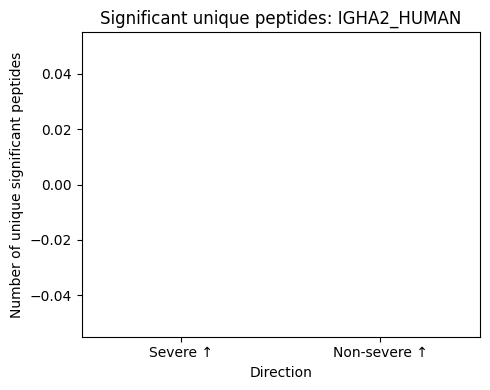

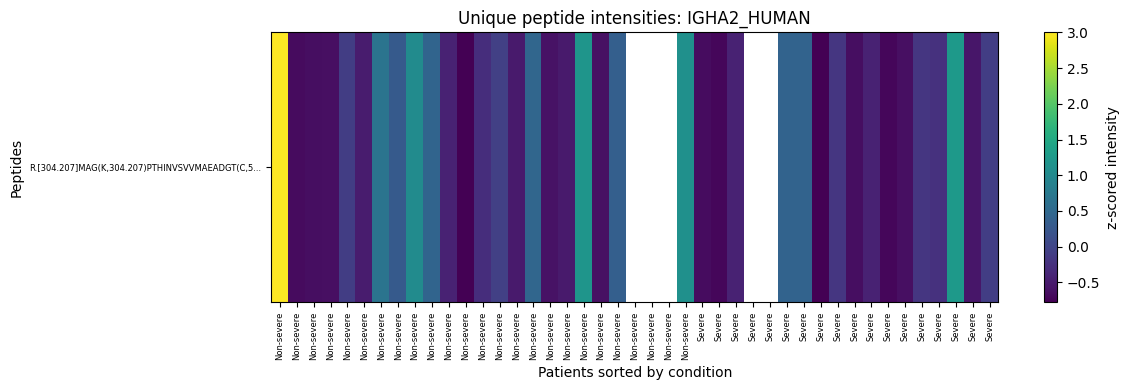

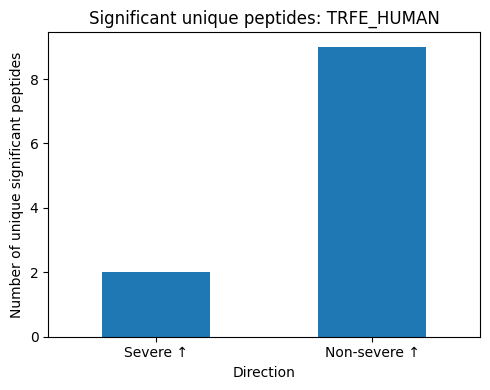

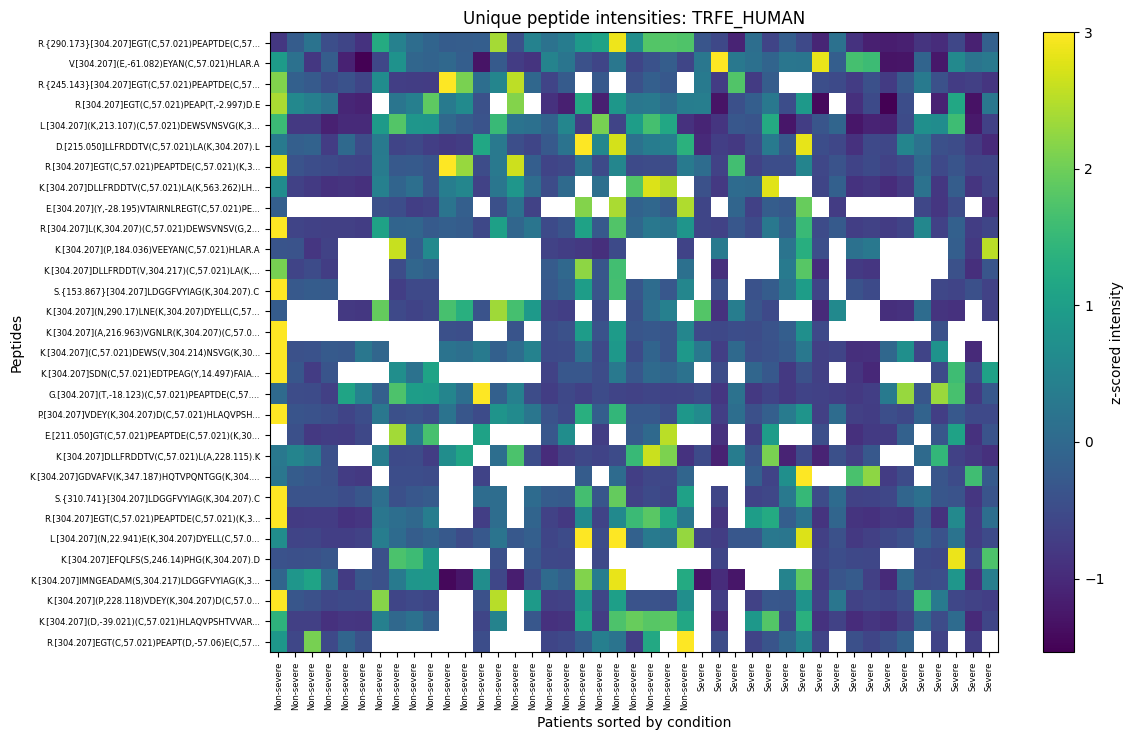

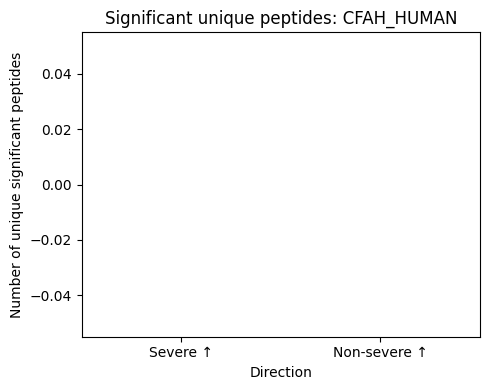

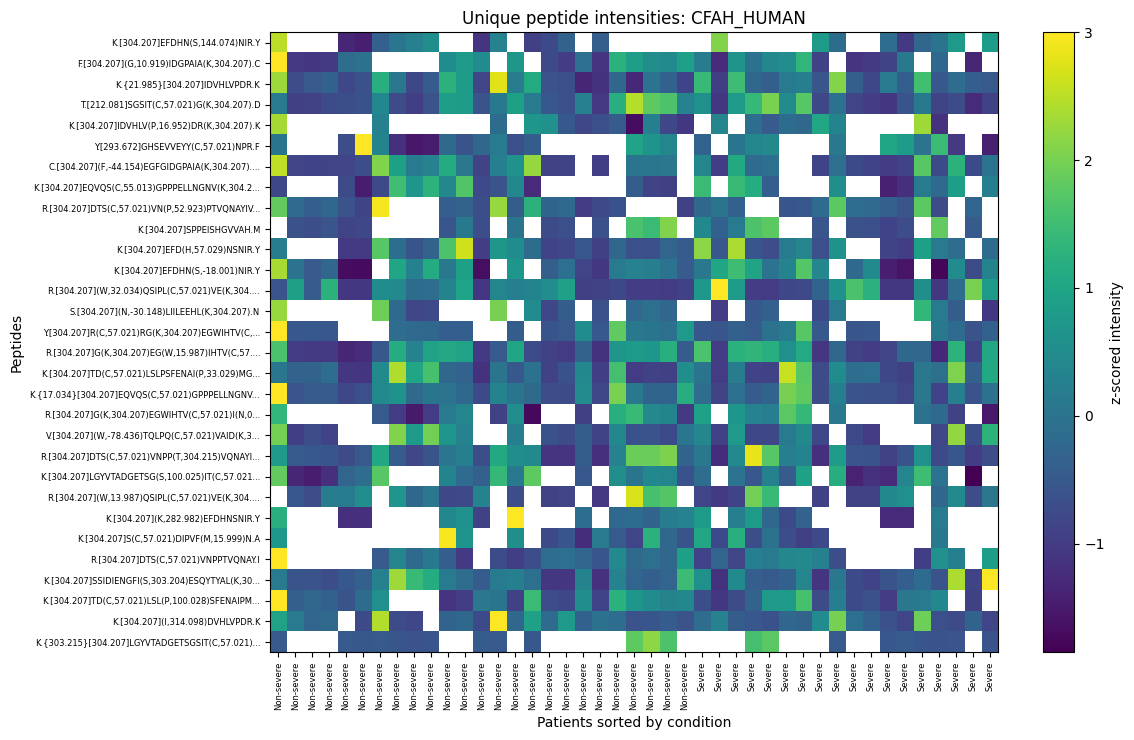

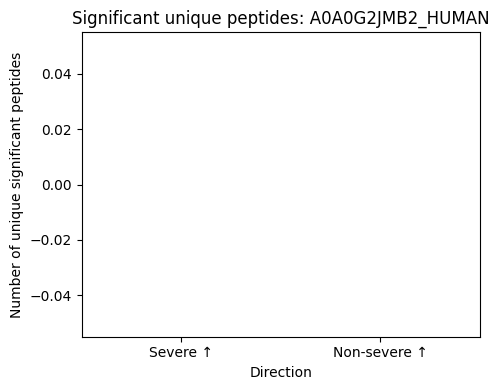

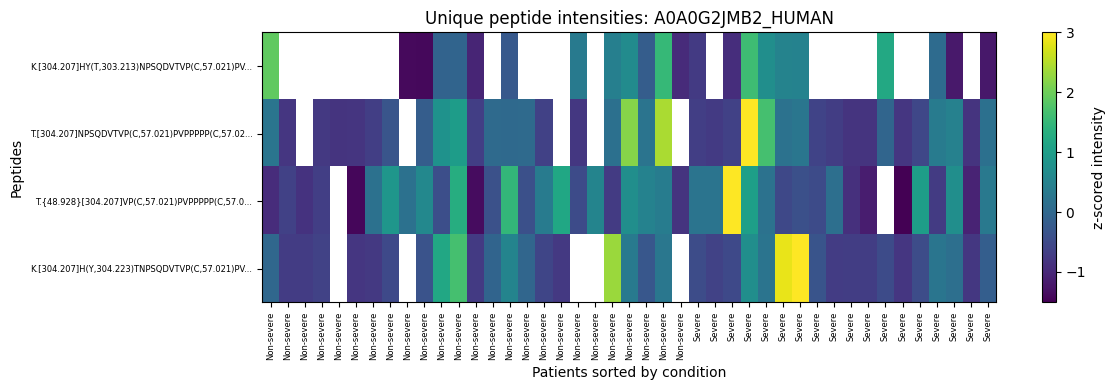

In [24]:
def safe_filename(text):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text))


def plot_direction_barplot(protein):
    g = protein_peptide_da[
        (protein_peptide_da["protein"] == protein)
        & (protein_peptide_da["usable_for_majority_rule"])
    ].copy()

    if g.empty:
        return

    counts = (
        g[g["raw_significant"]]
        .groupby("direction")["peptide"]
        .nunique()
        .reindex(["Severe ↑", "Non-severe ↑"], fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    counts.plot(kind="bar", ax=ax)

    ax.set_title(f"Significant unique peptides: {protein_short_name(protein)}")
    ax.set_ylabel("Number of unique significant peptides")
    ax.set_xlabel("Direction")
    ax.tick_params(axis="x", rotation=0)

    fig.tight_layout()

    out = OUTPUT_DIR / f"protein_{safe_filename(protein_short_name(protein))}_direction_barplot.png"
    fig.savefig(out, dpi=200)
    plt.show()


def plot_protein_heatmap(protein, max_peptides=30):
    g = protein_peptide_da[
        (protein_peptide_da["protein"] == protein)
        & (protein_peptide_da["usable_for_majority_rule"])
    ].copy()

    if g.empty:
        return

    # prioritize significant and then lowest p-values
    g = g.sort_values(["raw_significant", "mannwhitney_pvalue"], ascending=[False, True])
    peptides = g["peptide"].head(max_peptides).tolist()

    mat = X[peptides].copy()

    # z-score per peptide
    mat_z = mat.apply(lambda col: (col - col.mean(skipna=True)) / col.std(skipna=True), axis=0)
    mat_z = mat_z.clip(-3, 3)

    order = condition.sort_values().index
    mat_z = mat_z.loc[order]

    fig, ax = plt.subplots(figsize=(12, max(4, len(peptides) * 0.25)))
    im = ax.imshow(mat_z.T, aspect="auto", interpolation="nearest")

    ax.set_title(f"Unique peptide intensities: {protein_short_name(protein)}")
    ax.set_xlabel("Patients sorted by condition")
    ax.set_ylabel("Peptides")

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(condition.loc[order].str.replace("-COVID-19", "", regex=False), rotation=90, fontsize=6)

    ax.set_yticks(range(len(peptides)))
    ax.set_yticklabels([p[:45] + "..." if len(p) > 45 else p for p in peptides], fontsize=6)

    fig.colorbar(im, ax=ax, label="z-scored intensity")
    fig.tight_layout()

    out = OUTPUT_DIR / f"protein_{safe_filename(protein_short_name(protein))}_unique_peptides_heatmap.png"
    fig.savefig(out, dpi=200)
    plt.show()


for protein in candidate_proteins:
    plot_direction_barplot(protein)
    plot_protein_heatmap(protein)

In [26]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def accession_label(protein):
    if isinstance(protein, str) and "|" in protein:
        parts = protein.split("|")
        if len(parts) >= 3:
            return f"{parts[2]} ({parts[1]})"
    return str(protein)

def safe_name(text):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text))

# Make a compact report table from the majority-rule output
report_summary = protein_majority_summary.copy()

report_summary["protein_label"] = report_summary["protein"].apply(accession_label)

report_summary = report_summary[
    [
        "protein",
        "protein_label",
        "protein_short",
        "target_model_peptides",
        "target_peptide_unique_mapping",
        "n_total_mapped_peptides",
        "n_unique_testable_peptides",
        "n_unique_significant_peptides_raw_p",
        "n_unique_significant_severe_up",
        "n_unique_significant_nonsevere_up",
        "majority_direction",
        "majority_fraction",
        "effect_level_call",
        "mapping_caution",
    ]
].copy()

# Cleaner final interpretation labels
def final_interpretation(row):
    if "ambiguous" in str(row["mapping_caution"]).lower():
        if row["effect_level_call"] == "protein-level effect":
            return "Possible protein-level effect, but mapping is ambiguous"
        elif row["effect_level_call"] == "peptide-level effect":
            return "Peptide/variant-level effect with ambiguous protein assignment"
        elif row["effect_level_call"] == "no protein-level evidence":
            return "No protein-level evidence; ambiguous protein assignment"
        else:
            return "Inconclusive because of ambiguous mapping or insufficient unique peptides"

    if row["effect_level_call"] == "protein-level effect":
        return "Protein-level differential abundance"
    if row["effect_level_call"] == "peptide-level effect":
        return "Peptide-level or variant-level differential abundance"
    if row["effect_level_call"] == "no protein-level evidence":
        return "No protein-level differential abundance evidence"
    return "Inconclusive"

report_summary["final_interpretation"] = report_summary.apply(final_interpretation, axis=1)

report_summary.to_csv(
    OUTPUT_DIR / "protein_level_report_ready_summary.tsv",
    sep="\t",
    index=False,
)

display(report_summary)

,protein,protein_label,protein_short,target_model_peptides,target_peptide_unique_mapping,n_total_mapped_peptides,n_unique_testable_peptides,n_unique_significant_peptides_raw_p,n_unique_significant_severe_up,n_unique_significant_nonsevere_up,majority_direction,majority_fraction,effect_level_call,mapping_caution,final_interpretation
0,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN (P01876),IGHA1_HUMAN,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",False,1463,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...,Inconclusive because of ambiguous mapping or i...
1,sp|P01877|IGHA2_HUMAN,IGHA2_HUMAN (P01877),IGHA2_HUMAN,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",False,654,1,0,0,0,no_consistent_differential_abundance,0.000000,no protein-level evidence,target peptide maps to multiple proteins; prot...,No protein-level evidence; ambiguous protein a...
2,sp|P02787|TRFE_HUMAN,TRFE_HUMAN (P02787),TRFE_HUMAN,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",True,4288,878,11,2,9,mixed_or_minority_signal,0.010251,peptide-level effect,target peptide maps uniquely to this protein,Peptide-level or variant-level differential ab...
3,sp|P08603-2|CFAH_HUMAN,CFAH_HUMAN (P08603-2),CFAH_HUMAN,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",False,538,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...,Inconclusive because of ambiguous mapping or i...
4,sp|P08603|CFAH_HUMAN,CFAH_HUMAN (P08603),CFAH_HUMAN,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",False,1335,242,0,0,0,no_consistent_differential_abundance,0.000000,no protein-level evidence,target peptide maps to multiple proteins; prot...,No protein-level evidence; ambiguous protein a...
5,tr|A0A0D9SG88|A0A0D9SG88_HUMAN,A0A0D9SG88_HUMAN (A0A0D9SG88),A0A0D9SG88_HUMAN,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",False,523,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...,Inconclusive because of ambiguous mapping or i...
6,tr|A0A0G2JMB2|A0A0G2JMB2_HUMAN,A0A0G2JMB2_HUMAN (A0A0G2JMB2),A0A0G2JMB2_HUMAN,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",False,829,4,0,0,0,no_consistent_differential_abundance,0.000000,no protein-level evidence,target peptide maps to multiple proteins; prot...,No protein-level evidence; ambiguous protein a...
7,tr|A0A286YEY1|A0A286YEY1_HUMAN,A0A286YEY1_HUMAN (A0A286YEY1),A0A286YEY1_HUMAN,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",False,1456,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...,Inconclusive because of ambiguous mapping or i...
8,tr|A0A286YEY5|A0A286YEY5_HUMAN,A0A286YEY5_HUMAN (A0A286YEY5),A0A286YEY5_HUMAN,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",False,652,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...,Inconclusive because of ambiguous mapping or i...
9,tr|Q5TFM2|Q5TFM2_HUMAN,Q5TFM2_HUMAN (Q5TFM2),Q5TFM2_HUMAN,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",False,385,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...,Inconclusive because of ambiguous mapping or i...


In [27]:
# Keep only proteins directly connected to model-selected target peptides
direct_summary = report_summary[
    report_summary["target_model_peptides"].astype(str).str.len() > 0
].copy()

direct_summary = direct_summary.sort_values(
    ["target_peptide_unique_mapping", "n_unique_testable_peptides"],
    ascending=[False, False],
)

direct_summary.to_csv(
    OUTPUT_DIR / "protein_level_direct_target_summary.tsv",
    sep="\t",
    index=False,
)

display(direct_summary)

,protein,protein_label,protein_short,target_model_peptides,target_peptide_unique_mapping,n_total_mapped_peptides,n_unique_testable_peptides,n_unique_significant_peptides_raw_p,n_unique_significant_severe_up,n_unique_significant_nonsevere_up,majority_direction,majority_fraction,effect_level_call,mapping_caution,final_interpretation
2,sp|P02787|TRFE_HUMAN,TRFE_HUMAN (P02787),TRFE_HUMAN,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",True,4288,878,11,2,9,mixed_or_minority_signal,0.010251,peptide-level effect,target peptide maps uniquely to this protein,Peptide-level or variant-level differential ab...
4,sp|P08603|CFAH_HUMAN,CFAH_HUMAN (P08603),CFAH_HUMAN,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",False,1335,242,0,0,0,no_consistent_differential_abundance,0.000000,no protein-level evidence,target peptide maps to multiple proteins; prot...,No protein-level evidence; ambiguous protein a...
6,tr|A0A0G2JMB2|A0A0G2JMB2_HUMAN,A0A0G2JMB2_HUMAN (A0A0G2JMB2),A0A0G2JMB2_HUMAN,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",False,829,4,0,0,0,no_consistent_differential_abundance,0.000000,no protein-level evidence,target peptide maps to multiple proteins; prot...,No protein-level evidence; ambiguous protein a...
1,sp|P01877|IGHA2_HUMAN,IGHA2_HUMAN (P01877),IGHA2_HUMAN,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",False,654,1,0,0,0,no_consistent_differential_abundance,0.000000,no protein-level evidence,target peptide maps to multiple proteins; prot...,No protein-level evidence; ambiguous protein a...
0,sp|P01876|IGHA1_HUMAN,IGHA1_HUMAN (P01876),IGHA1_HUMAN,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",False,1463,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...,Inconclusive because of ambiguous mapping or i...
3,sp|P08603-2|CFAH_HUMAN,CFAH_HUMAN (P08603-2),CFAH_HUMAN,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",False,538,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...,Inconclusive because of ambiguous mapping or i...
5,tr|A0A0D9SG88|A0A0D9SG88_HUMAN,A0A0D9SG88_HUMAN (A0A0D9SG88),A0A0D9SG88_HUMAN,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",False,523,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...,Inconclusive because of ambiguous mapping or i...
7,tr|A0A286YEY1|A0A286YEY1_HUMAN,A0A286YEY1_HUMAN (A0A286YEY1),A0A286YEY1_HUMAN,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",False,1456,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...,Inconclusive because of ambiguous mapping or i...
8,tr|A0A286YEY5|A0A286YEY5_HUMAN,A0A286YEY5_HUMAN (A0A286YEY5),A0A286YEY5_HUMAN,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",False,652,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...,Inconclusive because of ambiguous mapping or i...
9,tr|Q5TFM2|Q5TFM2_HUMAN,Q5TFM2_HUMAN (Q5TFM2),Q5TFM2_HUMAN,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",False,385,0,0,0,0,insufficient_unique_testable_peptides,NaN,inconclusive,target peptide maps to multiple proteins; prot...,Inconclusive because of ambiguous mapping or i...


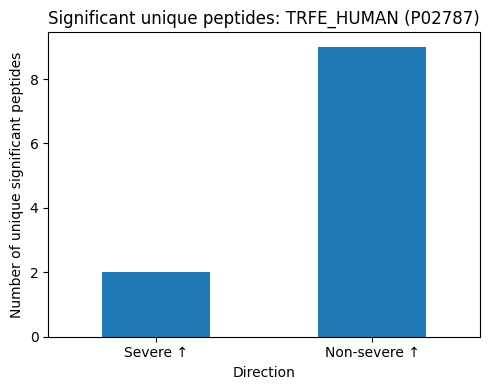

In [28]:
def plot_significant_direction_barplot(protein):
    g = protein_peptide_da[
        (protein_peptide_da["protein"] == protein)
        & (protein_peptide_da["usable_for_majority_rule"])
        & (protein_peptide_da["raw_significant"])
    ].copy()

    if g.empty:
        print(f"Skipping {accession_label(protein)}: no significant unique peptides.")
        return

    counts = (
        g.groupby("direction")["peptide"]
        .nunique()
        .reindex(["Severe ↑", "Non-severe ↑"], fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    counts.plot(kind="bar", ax=ax)

    ax.set_title(f"Significant unique peptides: {accession_label(protein)}")
    ax.set_ylabel("Number of unique significant peptides")
    ax.set_xlabel("Direction")
    ax.tick_params(axis="x", rotation=0)

    fig.tight_layout()

    out = OUTPUT_DIR / f"{safe_name(protein)}_significant_direction_barplot.png"
    fig.savefig(out, dpi=200)
    plt.show()

# Run only for proteins with significant unique peptides
proteins_with_sig = (
    protein_peptide_da[
        protein_peptide_da["usable_for_majority_rule"]
        & protein_peptide_da["raw_significant"]
    ]["protein"]
    .dropna()
    .unique()
)

for protein in proteins_with_sig:
    plot_significant_direction_barplot(protein)

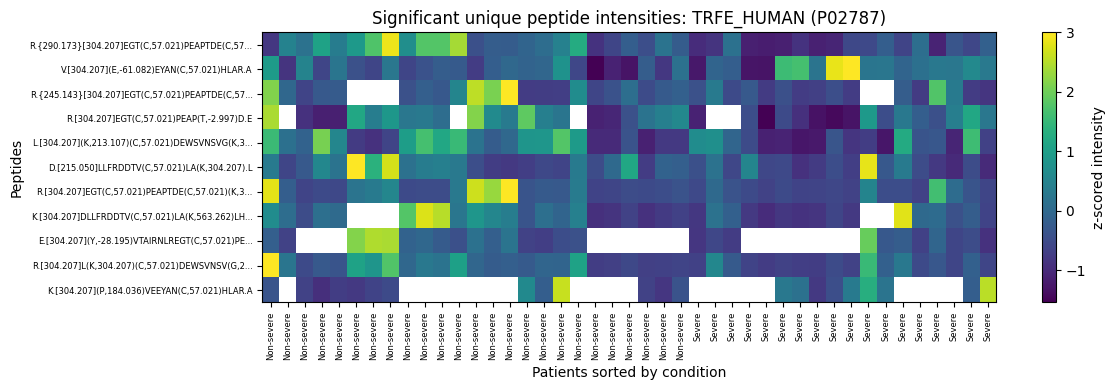

In [29]:
def plot_significant_unique_peptide_heatmap(protein, max_peptides=25):
    g = protein_peptide_da[
        (protein_peptide_da["protein"] == protein)
        & (protein_peptide_da["usable_for_majority_rule"])
        & (protein_peptide_da["raw_significant"])
    ].copy()

    if g.empty:
        print(f"Skipping heatmap for {accession_label(protein)}: no significant unique peptides.")
        return

    g = g.sort_values("mannwhitney_pvalue")
    peptides = g["peptide"].head(max_peptides).tolist()

    mat = X[peptides].copy()

    # z-score per peptide, keep NaN as missing/white
    mat_z = mat.apply(
        lambda col: (col - col.mean(skipna=True)) / col.std(skipna=True),
        axis=0
    ).clip(-3, 3)

    # Put Non-severe first, Severe second to match your peptide-level plots
    order = condition.map({
        "Non-severe-COVID-19": 0,
        "Severe-COVID-19": 1,
    }).sort_values().index

    mat_z = mat_z.loc[order]

    fig, ax = plt.subplots(figsize=(12, max(4, len(peptides) * 0.35)))
    im = ax.imshow(mat_z.T, aspect="auto", interpolation="nearest")

    ax.set_title(f"Significant unique peptide intensities: {accession_label(protein)}")
    ax.set_xlabel("Patients sorted by condition")
    ax.set_ylabel("Peptides")

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(
        condition.loc[order].str.replace("-COVID-19", "", regex=False),
        rotation=90,
        fontsize=6
    )

    ax.set_yticks(range(len(peptides)))
    ax.set_yticklabels(
        [p[:45] + "..." if len(p) > 45 else p for p in peptides],
        fontsize=6
    )

    fig.colorbar(im, ax=ax, label="z-scored intensity")
    fig.tight_layout()

    out = OUTPUT_DIR / f"{safe_name(protein)}_significant_unique_heatmap.png"
    fig.savefig(out, dpi=200)
    plt.show()

for protein in proteins_with_sig:
    plot_significant_unique_peptide_heatmap(protein)